In [1]:
# Data Handling
import pandas as pd
import numpy as np

#Visualization 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
from IPython.display import display
import io
%matplotlib inline

# NLP Preprocessing
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model Training & Evaluation
from sklearn.model_selection import train_test_split, GridSearchCV,train_test_split
from sklearn.linear_model import LogisticRegression,LassoCV,LinearRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder,StandardScaler

# Label Encoding
from sklearn.preprocessing import LabelEncoder

# Save/Load Model
import joblib

# Streamlit App (for later)
import streamlit as st

In [2]:
data = pd.read_csv("cleaned_data.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9912 entries, 0 to 9911
Data columns (total 49 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              9912 non-null   int64  
 1   video_id                9912 non-null   object 
 2   title                   9912 non-null   object 
 3   description             9912 non-null   object 
 4   published_at            9912 non-null   object 
 5   channel_id              9912 non-null   object 
 6   channel_title           9912 non-null   object 
 7   tags                    9912 non-null   object 
 8   tags_count              9912 non-null   int64  
 9   category_id             9912 non-null   int64  
 10  default_audio_language  9912 non-null   object 
 11  views                   9912 non-null   int64  
 12  likes                   9912 non-null   int64  
 13  comments                9912 non-null   int64  
 14  duration                9912 non-null   

#  Separating Columns by Type

## Numerical Features

## Categorical Features

# Boolean Features

# High-dimensional

# Dates

# Changing categorical column to multiple binary columns (0/1)

In [4]:
# Defining categorical features
categorical_features = [
    "category_id", "default_audio_language", "definition", "region_restriction",
    "license", "live_broadcast_content", "published_month_name",
    "published_weekday", "channel_month_name", "channel_weekday", "category_name"
]

# Initializing encoder
encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

# Fit and transform
encoded_array = encoder.fit_transform(data[categorical_features])

# Convert to DataFrame with proper column names
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(categorical_features),
    index=data.index
)

print("Original shape:", data.shape)
print("Encoded shape:", encoded_df.shape)
print("Example of encoded columns:")
print(encoded_df.head())

Original shape: (9912, 49)
Encoded shape: (9912, 194)
Example of encoded columns:
   category_id_2  category_id_10  category_id_15  category_id_17  \
0            0.0             0.0             0.0             0.0   
1            0.0             0.0             0.0             0.0   
2            0.0             0.0             0.0             0.0   
3            0.0             0.0             0.0             0.0   
4            0.0             0.0             0.0             0.0   

   category_id_19  category_id_20  category_id_22  category_id_23  \
0             0.0             0.0             0.0             0.0   
1             0.0             0.0             1.0             0.0   
2             0.0             0.0             0.0             1.0   
3             0.0             0.0             1.0             0.0   
4             0.0             0.0             0.0             0.0   

   category_id_24  category_id_25  ...  category_name_Gaming  \
0             0.0             

# Converting Boolean Columns to Integers 

In [5]:
# Defining boolean columns
boolean_features = ["caption", "licensed_content", "made_for_kids"]

# Converting boolean features to integers (0/1)
data[boolean_features] = data[boolean_features].astype(int)

print(data[boolean_features].head())
print(data[boolean_features].dtypes)

   caption  licensed_content  made_for_kids
0        0                 1              0
1        0                 1              0
2        0                 1              0
3        0                 1              0
4        0                 1              0
caption             int64
licensed_content    int64
made_for_kids       int64
dtype: object


# TF-IDF Vectorization per text column

In [6]:
# Defining the text_features
text_features = [
    "title", "description", "tags",
    "topic_categories", "channel_keywords", "channel_topics"
]

tfidf_dfs = []

for col in text_features:
    print(f"Vectorizing {col} ...")
    # Pick feature size depending on column length
    max_feats = 1000 if col in ["title", "tags"] else 2000
    
    tfidf = TfidfVectorizer(max_features=max_feats, stop_words="english")
    
    tfidf_matrix = tfidf.fit_transform(data[col].fillna(""))
    
    # Convert to DataFrame
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=[f"{col}_tfidf_{i}" for i in range(tfidf_matrix.shape[1])],
        index=data.index
    )
    
    tfidf_dfs.append(tfidf_df)

# Concatenate all text features together
text_encoded_df = pd.concat(tfidf_dfs, axis=1)

print("Final TF-IDF shape (all text fields):", text_encoded_df.shape)
print(text_encoded_df.head())

Vectorizing title ...
Vectorizing description ...
Vectorizing tags ...
Vectorizing topic_categories ...
Vectorizing channel_keywords ...
Vectorizing channel_topics ...
Final TF-IDF shape (all text fields): (9912, 6138)
   title_tfidf_0  title_tfidf_1  title_tfidf_2  title_tfidf_3  title_tfidf_4  \
0            0.0            0.0            0.0            0.0            0.0   
1            0.0            0.0            0.0            0.0            0.0   
2            0.0            0.0            0.0            0.0            0.0   
3            0.0            0.0            0.0            0.0            0.0   
4            0.0            0.0            0.0            0.0            0.0   

   title_tfidf_5  title_tfidf_6  title_tfidf_7  title_tfidf_8  title_tfidf_9  \
0            0.0            0.0            0.0            0.0            0.0   
1            0.0            0.0            0.0            0.0            0.0   
2            0.0            0.0            0.0            0.

# Combining the formatted columns to use in my modelling

In [7]:
# Drop the old categorical columns (since we now have encoded_df instead)
data_cleaned = data.drop(columns=categorical_features)

# Concatenate encoded features
data_final = pd.concat([data_cleaned, encoded_df], axis=1)

print("Final dataset shape:", data_final.shape)


Final dataset shape: (9912, 232)


# Define features (X) and target (y)

In [8]:
# Quick check
print(data_final.dtypes.value_counts())

float64    199
int64       20
object      13
Name: count, dtype: int64


In [9]:
non_numeric = data_final.select_dtypes(include=["object"])
print("Remaining object columns:", non_numeric.columns.tolist())

Remaining object columns: ['video_id', 'title', 'description', 'published_at', 'channel_id', 'channel_title', 'tags', 'topic_categories', 'channel_created_at', 'channel_keywords', 'channel_topics', 'published_date', 'channel_date']


video_id → unique ID, no predictive value → drop

channel_id → unique ID, no predictive value → drop

channel_title → just a label, highly correlated with channel_id → drop

published_at → raw timestamp; you already have published_year, published_month, etc. → drop

published_date → same reason as above → drop

channel_created_at / channel_date → you already have channel_year, channel_month, etc. → drop

In [10]:
drop_cols = [
    "video_id", "title", "description", "published_at", "channel_id", 
    "channel_title", "tags", "channel_created_at", "channel_keywords", 
    "channel_topics", "published_date", "channel_date","topic_categories",'Unnamed: 0',
]
data_final = data_final.drop(columns=drop_cols, errors="ignore")

print(data_final.dtypes.value_counts())
print("Final dataset shape:", data_final.shape)

float64    199
int64       19
Name: count, dtype: int64
Final dataset shape: (9912, 218)


In [11]:
data_final.columns.tolist()

['tags_count',
 'views',
 'likes',
 'comments',
 'duration',
 'caption',
 'licensed_content',
 'made_for_kids',
 'channel_views',
 'channel_subscribers',
 'channel_total_videos',
 'published_year',
 'published_month',
 'published_day_date',
 'channel_year',
 'channel_month',
 'channel_day_date',
 'view_rate',
 'like_rate',
 'comment_rate',
 'title_sentiment',
 'desc_sentiment',
 'title_length',
 'desc_length',
 'category_id_2',
 'category_id_10',
 'category_id_15',
 'category_id_17',
 'category_id_19',
 'category_id_20',
 'category_id_22',
 'category_id_23',
 'category_id_24',
 'category_id_25',
 'category_id_26',
 'category_id_27',
 'category_id_28',
 'category_id_29',
 'default_audio_language_ar',
 'default_audio_language_as',
 'default_audio_language_ase',
 'default_audio_language_az',
 'default_audio_language_be',
 'default_audio_language_bh',
 'default_audio_language_bm',
 'default_audio_language_bn',
 'default_audio_language_bn-IN',
 'default_audio_language_brx',
 'default_audio_

# Defining features (X) and target (y):

In [14]:
# Define target
target = "like_rate"
y = data_final[target]

# Define features (drop target + leakage columns)
leakage_cols = [
    "views", "likes", "dislikes", "comments",   # raw engagement counts
    "like_rate", "comment_rate", "view_rate",   # derived ratios (avoid target leakage)
    "video_id", "title", "description", "published_at", "channel_id",
    "channel_title", "tags", "topic_categories",
    "channel_created_at", "channel_keywords", "channel_topics",
    "published_date", "channel_date"
]

X = data_final.drop(columns=leakage_cols, errors="ignore")

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (9912, 212)
Target shape: (9912,)


# Modelling

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [17]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),
    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    )
}


In [22]:
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

X_train.columns = (
    X_train.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
)

X_test.columns = X_train.columns  # keep same order


In [24]:
import re

def clean_feature_names(df):
    df = df.copy()
    df.columns = (
        df.columns
        .astype(str)
        .str.lower()
        .str.replace(r"[^\w]+", "_", regex=True)  # keep only a-z, 0-9, _
        .str.strip("_")
    )
    return df


In [25]:
X_train = clean_feature_names(X_train)
X_test = clean_feature_names(X_test)

# ensure same column order
X_test = X_test[X_train.columns]


In [26]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001447 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2154
[LightGBM] [Info] Number of data points in the train set: 7929, number of used features: 100
[LightGBM] [Info] Start training from score 0.029141


In [27]:
results_df = (
    pd.DataFrame(results)
    .sort_values(by="R2", ascending=False)
    .reset_index(drop=True)
)

results_df


,Model,R2,RMSE,MAE
0,Random Forest,0.208468,0.027746,0.012509
1,Random Forest,0.208468,0.027746,0.012509
2,LightGBM,0.204176,0.027821,0.012290
3,XGBoost,0.194651,0.027987,0.012583
4,XGBoost,0.194651,0.027987,0.012583
5,CatBoost,0.182650,0.028195,0.013068
6,Gradient Boosting,0.157163,0.028631,0.013726
7,Gradient Boosting,0.157163,0.028631,0.013726
8,Ridge Regression,0.050841,0.030383,0.016298
9,Ridge Regression,0.050841,0.030383,0.016298


## LinearRegression

In [124]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize model
lin_reg = LinearRegression()

# Fit model
lin_reg.fit(X_train, y_train)

# Predictions
y_pred = lin_reg.predict(X_test)

# Evaluation
print("R² score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Feature importance (coefficients)
coeffs = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lin_reg.coef_
}).sort_values(by="coefficient", ascending=False)

print(coeffs.head(10))   # top positive drivers
print(coeffs.tail(10))   # top negative drivers


R² score: 0.052106110411951456
RMSE: 0.03036314876531573
                                               feature  coefficient
54                        default_audio_language_es-ES     0.040329
74                           default_audio_language_ne     0.034728
104                       default_audio_language_zh-TW     0.031463
130  region_restriction_{'blocked': ['AE', 'AM', 'B...     0.022978
53                       default_audio_language_es-419     0.022342
58                          default_audio_language_fil     0.021117
101                       default_audio_language_zh-HK     0.019363
113  region_restriction_{'allowed': ['AD', 'AE', 'A...     0.018456
69                           default_audio_language_kn     0.016846
103                     default_audio_language_zh-Hant     0.015220
                                               feature  coefficient
98                           default_audio_language_vi    -0.012063
61                           default_audio_language_gu    -

- Your linear regression explains only ~5% of variance basically, the model is not capturing much.

## RandomForest

In [125]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R² score (RF):", r2_score(y_test, y_pred_rf))
print("RMSE (RF):", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

# Feature importance
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importances.head(15))


R² score (RF): 0.2053242602405152
RMSE (RF): 0.027801096359229713
                 feature  importance
1               duration    0.160498
5          channel_views    0.107565
6    channel_subscribers    0.076368
7   channel_total_videos    0.068340
8         published_year    0.052909
16          title_length    0.040604
13      channel_day_date    0.039045
10    published_day_date    0.038884
15        desc_sentiment    0.037539
17           desc_length    0.035273
14       title_sentiment    0.033582
9        published_month    0.031106
11          channel_year    0.029279
12         channel_month    0.021776
4          made_for_kids    0.018773


## XGBOOST

In [126]:
# Clean feature names (remove problematic characters)
X_train.columns = X_train.columns.str.replace(r"[^A-Za-z0-9_]+", "_", regex=True)
X_test.columns  = X_test.columns.str.replace(r"[^A-Za-z0-9_]+", "_", regex=True)

In [128]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# Initialize XGBoost Regressor
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Fit
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Evaluate
print("R² score (XGB):", r2_score(y_test, y_pred_xgb))
print("RMSE (XGB):", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

# Feature importance
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importances.head(15))


R² score (XGB): 0.1998671583266176
RMSE (XGB): 0.027896389220204015
                            feature  importance
4                     made_for_kids    0.070351
106                   definition_sd    0.044199
163     live_broadcast_content_none    0.042207
164     published_month_name_August    0.028694
8                    published_year    0.022758
204             category_name_Music    0.021919
199         category_name_Education    0.019645
29                   category_id_27    0.019505
19                   category_id_10    0.018603
201  category_name_Film & Animation    0.017495
27                   category_id_25    0.014698
1                          duration    0.014138
49     default_audio_language_en-GB    0.013513
23                   category_id_20    0.012441
162                 license_youtube    0.012397


- Category dominates: Whether something is Music, Education, Film, etc. is one of the strongest drivers.
- Platform rules matter: Made for Kids, license, definition strongly influence exposure.
- Seasonality exists: Month of publishing (August in your case) is statistically important.
- Duration is secondary: Content type and metadata matter more than length.

# Top 20 feature importance plots for both RandomForest & XGBoost

## saving the RandomForest and XGBoost feature importance DataFrames into variables

In [129]:
# RandomForest feature importance
rf_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

# XGBoost feature importance
xgb_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)


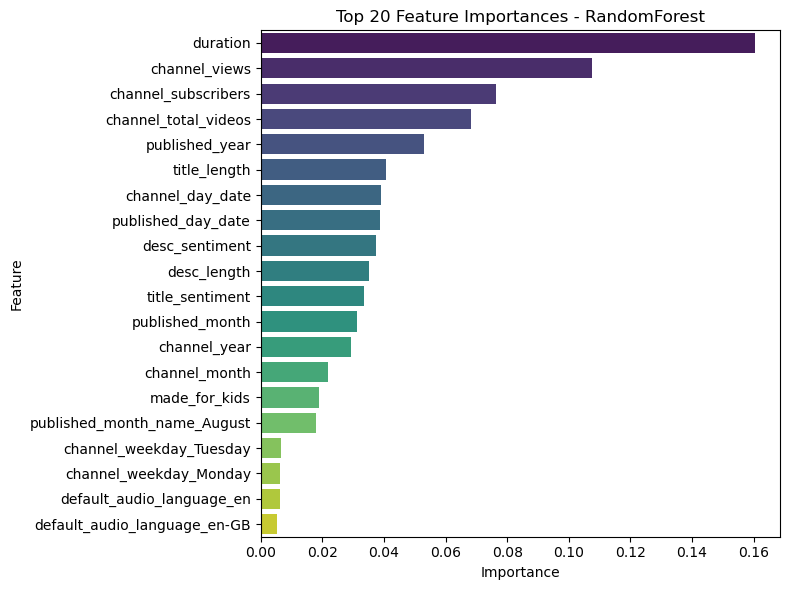

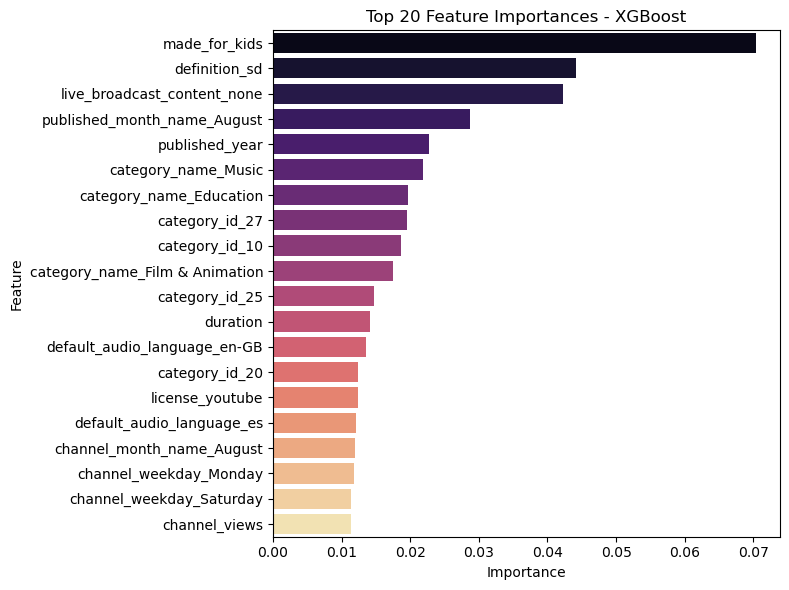

Overlapping Top Features: {'default_audio_language_en-GB', 'channel_weekday_Monday', 'published_year', 'published_month_name_August', 'channel_views', 'made_for_kids', 'duration'}
Unique to RandomForest: {'title_sentiment', 'channel_total_videos', 'channel_day_date', 'default_audio_language_en', 'desc_sentiment', 'channel_weekday_Tuesday', 'channel_subscribers', 'published_month', 'channel_month', 'channel_year', 'title_length', 'desc_length', 'published_day_date'}
Unique to XGBoost: {'category_id_27', 'category_id_10', 'category_name_Music', 'default_audio_language_es', 'category_name_Education', 'category_id_25', 'channel_weekday_Saturday', 'category_name_Film & Animation', 'live_broadcast_content_none', 'category_id_20', 'license_youtube', 'definition_sd', 'channel_month_name_August'}


In [130]:
# RandomForest top 20 
rf_top20 = rf_importances.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(8, 6))
sns.barplot(x="importance", y="feature", data=rf_top20, palette="viridis",hue="feature")
plt.title("Top 20 Feature Importances - RandomForest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# XGBoost top 20 
xgb_top20 = xgb_importances.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(8, 6))
sns.barplot(x="importance", y="feature", data=xgb_top20, palette="magma",hue="feature")
plt.title("Top 20 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Compare overlap 
rf_features = set(rf_top20["feature"])
xgb_features = set(xgb_top20["feature"])

overlap = rf_features.intersection(xgb_features)
unique_rf = rf_features - xgb_features
unique_xgb = xgb_features - rf_features

print("Overlapping Top Features:", overlap)
print("Unique to RandomForest:", unique_rf)
print("Unique to XGBoost:", unique_xgb)


- Both models agree on the big universal drivers: duration, time, channel authority, and audience type.
- RandomForest leans toward how the video is written/presented (textual/metadata).
- XGBoost leans toward what the video is about and how it’s technically configured (category, language, definition).
- Both agree: duration, channel authority, publishing time, and made_for_kids drive a lot of the performance.

# Fine-tuning Random Forest

In [135]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "n_estimators": [200, 500],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=3,
    n_jobs=-1,
    scoring="r2",
    verbose=2
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best params (RF):", grid_rf.best_params_)
print("Best CV R² (RF):", grid_rf.best_score_)



Fitting 3 folds for each of 144 candidates, totalling 432 fits
Best params (RF): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV R² (RF): 0.2946657594208624


## Retrain Best RF on Full Train Set

In [136]:
best_rf = grid_rf.best_estimator_

# Fit on training data
best_rf.fit(X_train, y_train)

# Predict on test set
y_pred_rf = best_rf.predict(X_test)


[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   0.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   1.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=500; total time=   3.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   3.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   3.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   3.1s
[CV] END max_depth=10, max_features=sq

## Evaluate on Test Data

In [140]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Evaluate Random Forest
r2 = r2_score(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))  # manually take sqrt
mae = mean_absolute_error(y_test, y_pred_rf)
mape = (abs((y_test - y_pred_rf) / y_test).mean()) * 100

print("Random Forest Test Performance:")
print(f"Test R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test MAPE: {mape:.2f}%")


Random Forest Test Performance:
Test R²: 0.1898
Test RMSE: 0.0281
Test MAE: 0.0132
Test MAPE: inf%


- The model explains about 19% of the variation in performance the remaining 81% is “unexplained noise”.
- R² tends to be low because engagement is influenced by many hidden factors
- An RMSE of 0.0281 ≈ 2.8% means predictions are usually off by about 2.8 percentage points.
- The model predicts like_rate within ~1–1.5 percentage points of the true value most of the time.
- MAPE failed because some videos had a target value of 0 (zero rate).Since MAPE divides by the actual value, division by zero leads to inf%.
- The Random Forest model is learning some useful patterns (duration, channel size, publish time, etc.), but it’s not very strong (R² only ~19%

# Fine tuning XGBoost

In [161]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

param_dist_xgb = {
    "n_estimators": [200, 500, 800],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7]
}

xgb = XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1)

random_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=50, 
    cv=3,
    n_jobs=-1,
    scoring="r2",
    verbose=2,
    random_state=42
)

random_xgb.fit(X_train, y_train)

best_xgb = random_xgb.best_estimator_
print("Best params (XGB):", random_xgb.best_params_)
print("Best CV R² (XGB):", random_xgb.best_score_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best params (XGB): {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Best CV R² (XGB): 0.35892205862070314


- XGBoost is clearly outperforming Random Forest on your dataset.Random Forest Test R² was only ~0.19, while XGB CV R² is ~0.36

# Elevaluating the fine-tuned XGB model

In [149]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Use best XGB
best_xgb = random_xgb.best_estimator_

# Fit on training set
best_xgb.fit(X_train, y_train)

# Predict on test
y_pred_xgb = best_xgb.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae = mean_absolute_error(y_test, y_pred_xgb)
smape = (100/len(y_test)) * np.sum(2 * np.abs(y_test - y_pred_xgb) / (np.abs(y_test) + np.abs(y_pred_xgb)))

print("XGBoost Test Performance:")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"SMAPE: {smape:.2f}%")


XGBoost Test Performance:
R²: 0.2094
RMSE: 0.0277
MAE: 0.0123
SMAPE: 46.82%


- The tuned XGB explains about 21% of the variance in your target on unseen test data.

In [150]:
import joblib

In [164]:
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

In [166]:
# Saving the model
joblib.dump(best_xgb, "like_rate_model.pkl")

['like_rate_model.pkl']